# Introduction to Logistic Regression and Clustering with K-Means

In this notebook, we will explore the fundamental libraries used for classification and clustering problems in Python.

We'll first generate a dummy dataset, create a binary classification problem, train a Logistic Regression model, and evaluate its performance using standard metrics.

Then, we'll apply **K-Means Clustering** to explore hidden patterns in the data. We'll demonstrate how to use the **Elbow Method** and **Silhouette Score** to choose the optimal number of clusters.

## Logistic Regression Evaluation Metrics
- **Accuracy**: Proportion of correctly predicted instances.
- **Precision**: Proportion of predicted positives that are actually positive.
- **Recall**: Proportion of actual positives that were correctly predicted.
- **F1 Score**: Harmonic mean of precision and recall.
- **Confusion Matrix**: Summarizes prediction results.

### Evaluation Metric Formulas:
- Accuracy:
$$ \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} $$

- Precision:
$$ \text{Precision} = \frac{TP}{TP + FP} $$

- Recall:
$$ \text{Recall} = \frac{TP}{TP + FN} $$

- F1 Score:
$$ \text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} $$

Where:
- TP = True Positives
- TN = True Negatives
- FP = False Positives
- FN = False Negatives

## K-Means Clustering Concepts

### Elbow Method:
The Elbow Method is used to find the optimal number of clusters (k) in K-Means by plotting the within-cluster sum of squares (inertia) against k. The 'elbow point' is where the rate of decrease sharply slows, indicating diminishing returns for adding more clusters.

### Inertia:
Inertia measures the compactness of the clusters. It is defined as the sum of squared distances between each point and its assigned cluster centroid.

$$ \text{Inertia} = \sum_{i=1}^{k} \sum_{x_j \in C_i} \| x_j - \mu_i \|^2 $$

Where:
- \( k \): number of clusters
- \( x_j \): data point assigned to cluster \( C_i \)
- \( \mu_i \): centroid of cluster \( C_i \)

Lower inertia means tighter clusters.

### Silhouette Score:
The Silhouette Score measures how similar a data point is to its own cluster compared to other clusters. Values range from -1 to 1:
- **1**: Perfectly matched to its own cluster and well-separated from others.
- **0**: On or very close to the decision boundary between two clusters.
- **-1**: Incorrectly assigned to the wrong cluster.

Higher silhouette scores indicate better-defined clusters.
"""

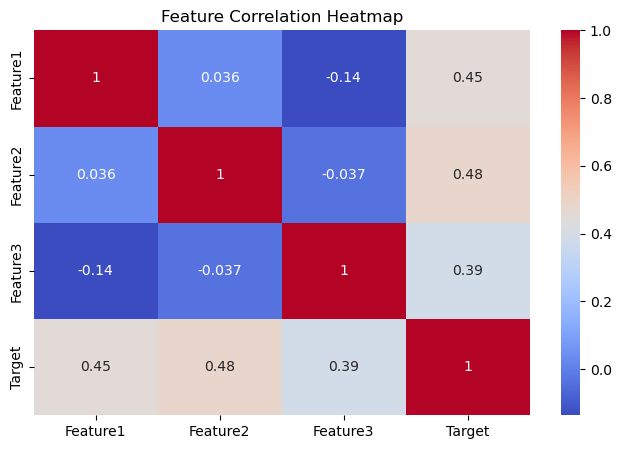

,Feature1,Feature2,Feature3,Target
0,3.745401,9.082659,0.516817,0
1,9.507143,2.395619,5.313546,1
2,7.319939,1.448949,5.406351,0
3,5.986585,4.894528,6.374299,1
4,1.560186,9.856505,7.260913,1


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Generate dummy dataset
np.random.seed(42)
n_samples = 150
X1 = np.random.rand(n_samples) * 10
X2 = np.random.rand(n_samples) * 10
X3 = np.random.rand(n_samples) * 10

# Binary target: 1 if sum of features > 15, else 0
Y = ((X1 + X2 + X3) > 15).astype(int)

df = pd.DataFrame({
    'Feature1': X1,
    'Feature2': X2,
    'Feature3': X3,
    'Target': Y
})

plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

df.head()

In [2]:
X = df[['Feature1', 'Feature2', 'Feature3']]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.2f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.93
Precision: 0.93
Recall: 0.93
F1 Score: 0.93
Confusion Matrix:
[[15  1]
 [ 1 13]]


d:\Info\AnacondaFolder\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Info\AnacondaFolder\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Info\AnacondaFolder\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Info\AnacondaFolder\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with M

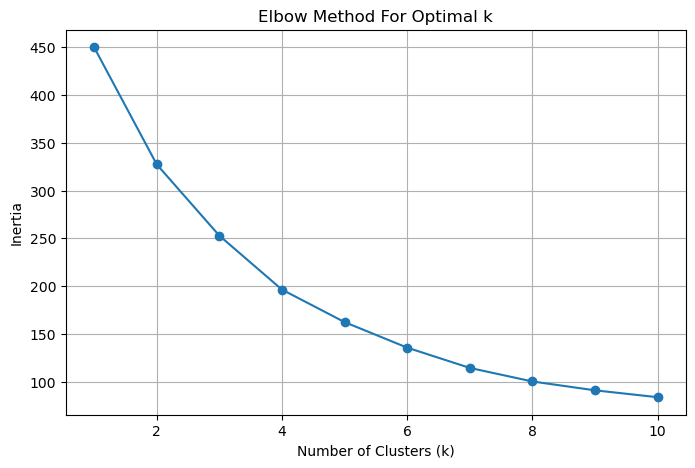

d:\Info\AnacondaFolder\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Info\AnacondaFolder\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Info\AnacondaFolder\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Info\AnacondaFolder\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with M

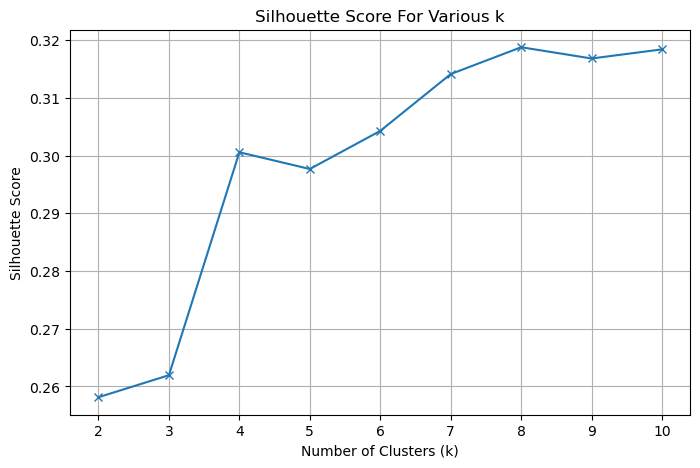

d:\Info\AnacondaFolder\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


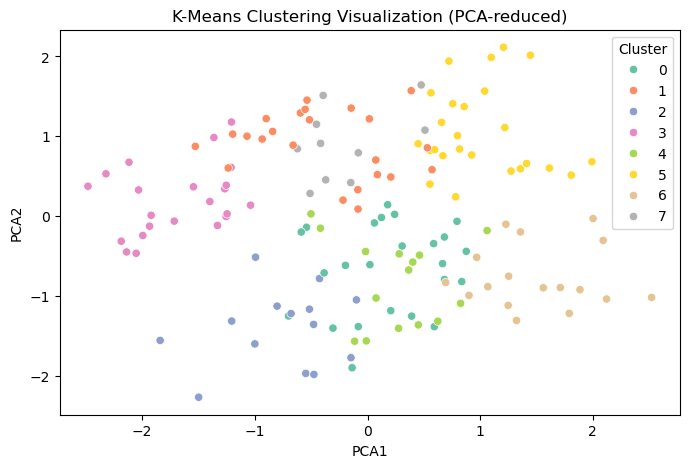

In [3]:
features_for_clustering = df[['Feature1', 'Feature2', 'Feature3']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_for_clustering)

inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_init=10, n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid()
plt.show()

# Silhouette Score for different k
silhouette_scores = []
k_vals = range(2, 11)
for k in k_vals:
    kmeans = KMeans(n_init=10, n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(k_vals, silhouette_scores, marker='x')
plt.title('Silhouette Score For Various k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid()
plt.show()

kmeans = KMeans(n_init=10, n_clusters=8, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)
df['PCA1'] = components[:, 0]
df['PCA2'] = components[:, 1]

plt.figure(figsize=(8, 5))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set2')
plt.title("K-Means Clustering Visualization (PCA-reduced)")
plt.show()
